In [24]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import glob

In [11]:
def load_file(filename):
    rows = []
    filename
    with open(filename, "r") as f:
        for line in f:
            pairs = re.findall(r"([\w' ]+):\s*(-?[0-9]*\.?[0-9]+)", line)
            if pairs:
                rows.append(dict(pairs))

    return(pd.DataFrame(rows))

In [22]:
fedavg = {
    "FedAVG iid Base": load_file("FedAVG_lr_iid_Base.txt"),
    "FedAVG iid 1": load_file("FedAVG_lr_iid_1.txt"),
    "FedAVG iid 2": load_file("FedAVG_lr_iid_2.txt"),
    "FedAVG non Base": load_file("FedAVG_lr_non_Base.txt"),
    "FedAVG non 1": load_file("FedAVG_lr_non_1.txt"),
    "FedAVG non 2": load_file("FedAVG_lr_non_2.txt")
}
fedprox = {
    "FedProx iid Base": load_file("FedProx_lr_iid_Base.txt"),
    "FedProx iid 1": load_file("FedProx_lr_iid_1.txt"),
    "FedProx iid 2": load_file("FedProx_lr_iid_2.txt"),
    "FedProx non Base": load_file("FedProx_lr_non_Base.txt"),
    "FedProx non 1": load_file("FedProx_lr_non_1.txt"),
    "FedProx non 2": load_file("FedProx_lr_non_2.txt"),
}

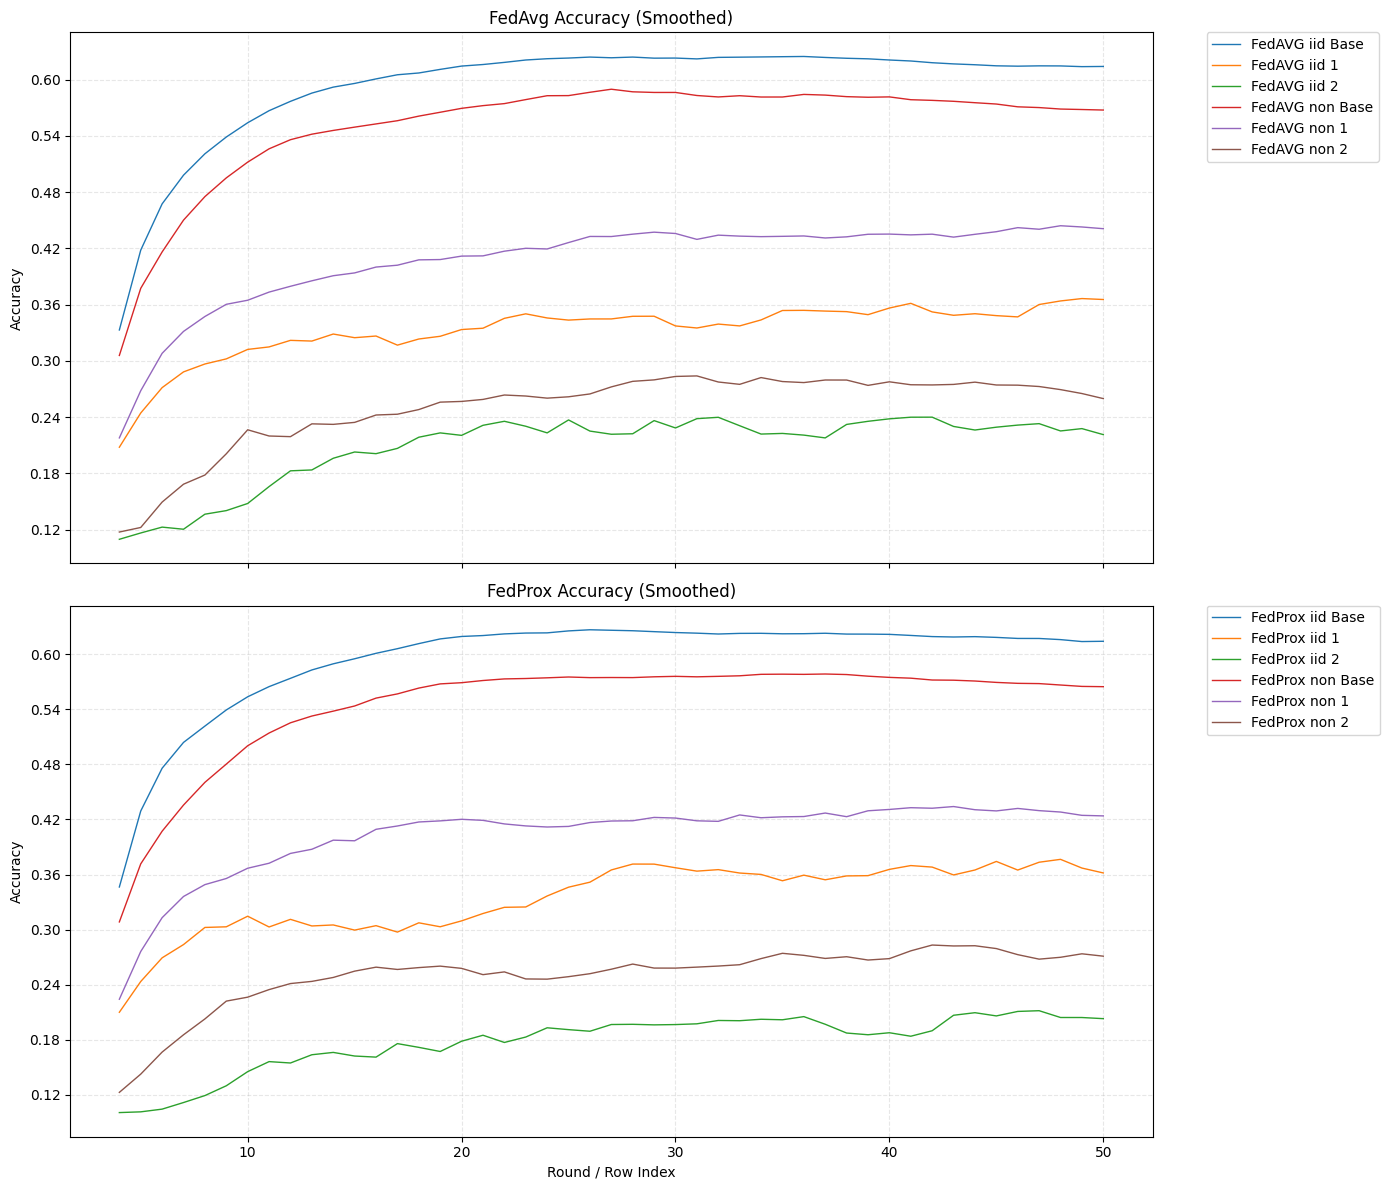

In [ ]:
plt.style.use("default")
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)


for label, df in fedavg.items():
    acc_smooth = df["Accuracy"].rolling(5).mean()
    axes[0].plot(acc_smooth, label=label, linewidth=1, marker=None)
axes[0].set_title("FedAvg Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, linestyle="--", alpha=0.3)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axes[0].yaxis.set_major_locator(ticker.MaxNLocator(10))


for label, df in fedprox.items():
    acc_smooth = df["Accuracy"].rolling(5).mean()
    axes[1].plot(acc_smooth, label=label, linewidth=1, marker=None)
axes[1].set_title("FedProx Accuracy")
axes[1].set_xlabel("Round / Row Index")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, linestyle="--", alpha=0.3)
# Move legend outside and limit y-ticks
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axes[1].yaxis.set_major_locator(ticker.MaxNLocator(10))

plt.tight_layout()
plt.show()

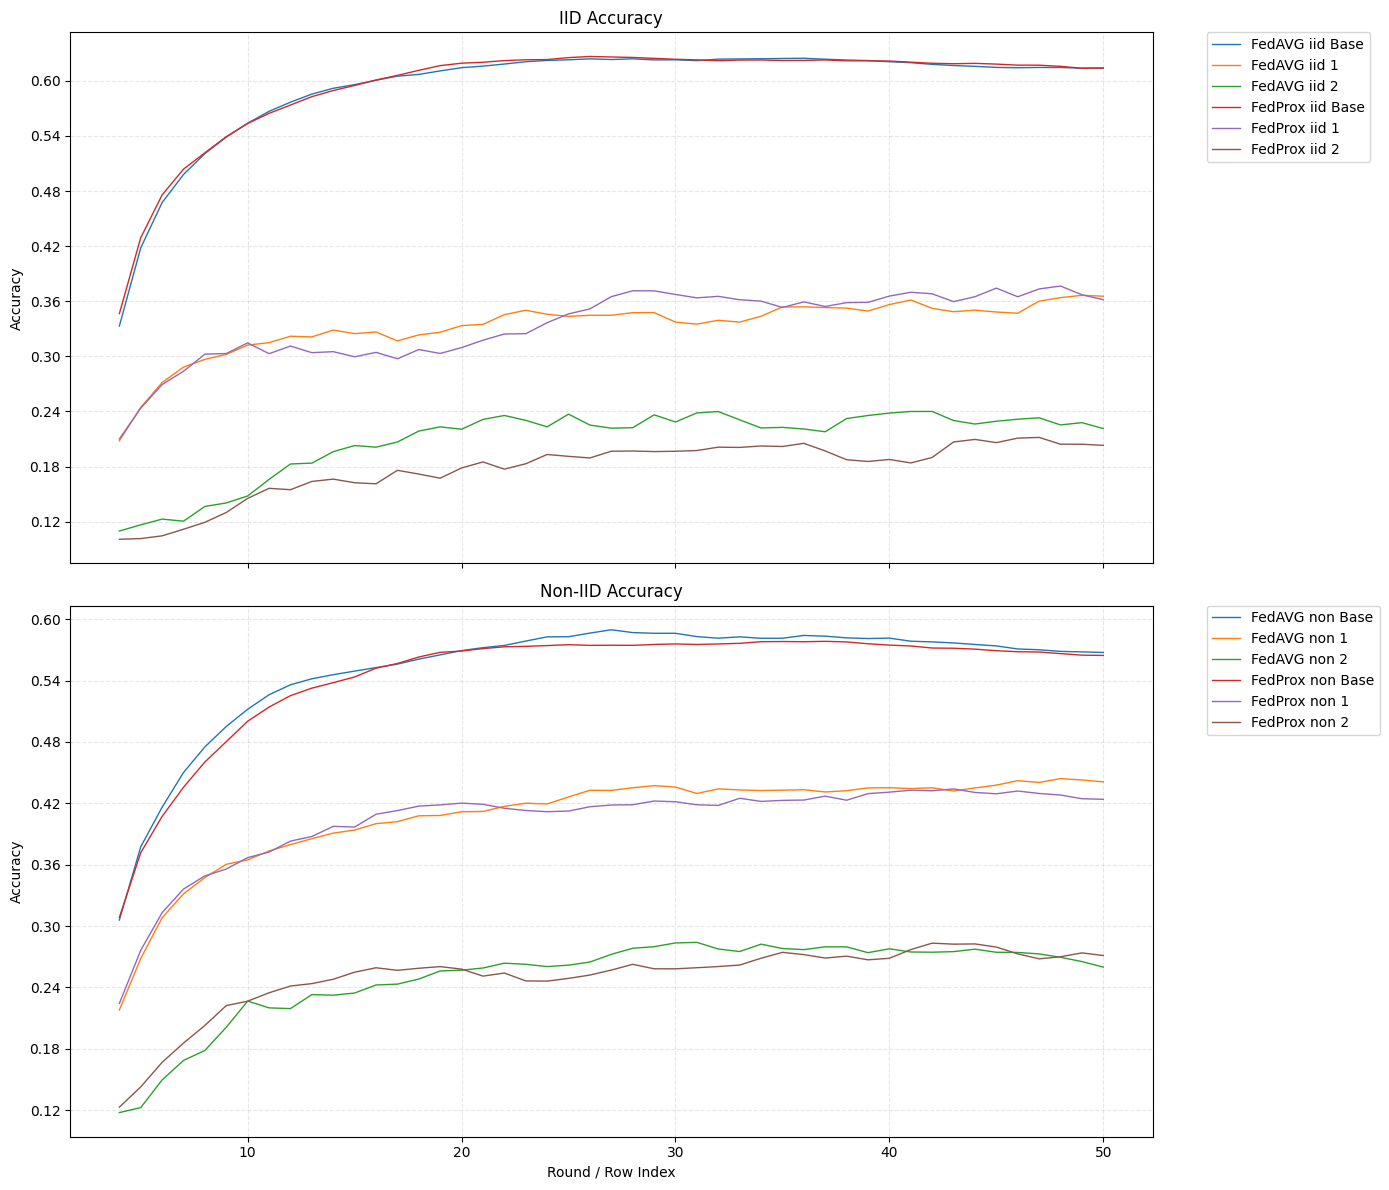

In [ ]:

iid_dfs = {k: v for k, v in fedavg.items() if "iid" in k}
iid_dfs.update({k: v for k, v in fedprox.items() if "iid" in k})

non_dfs = {k: v for k, v in fedavg.items() if "non" in k}
non_dfs.update({k: v for k, v in fedprox.items() if "non" in k})


fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

for label, df in iid_dfs.items():
    acc_smooth = df["Accuracy"].rolling(5).mean()
    axes[0].plot(acc_smooth, label=label, linewidth=1, marker=None)
axes[0].set_title("IID Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, linestyle="--", alpha=0.3)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axes[0].yaxis.set_major_locator(ticker.MaxNLocator(10))


for label, df in non_dfs.items():
    acc_smooth = df["Accuracy"].rolling(5).mean()
    axes[1].plot(acc_smooth, label=label, linewidth=1, marker=None)
axes[1].set_title("Non-IID Accuracy")
axes[1].set_xlabel("Round / Row Index")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, linestyle="--", alpha=0.3)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axes[1].yaxis.set_major_locator(ticker.MaxNLocator(10))
plt.tight_layout()